In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.simplefilter("ignore")

In [81]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\data\taxi_trip_pricing.csv")
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


# Business Problem

This dataset is designed to predict taxi trip fares based on various factors such as distance, time of day, traffic conditions, and more. It provides realistic synthetic data for regression tasks, offering a unique opportunity to explore pricing trends in the taxi industry.

Key Features

Distance (in kilometers): The length of the trip.
Pickup Time: The starting time of the trip.
Dropoff Time: The ending time of the trip.
Traffic Condition: Categorical indicator of traffic (light, medium, heavy).
Passenger Count: Number of passengers for the trip.
Weather Condition: Categorical data for weather (clear, rain, snow).
Trip Duration (in minutes): Total trip time.
Fare Amount (target): The cost of the trip (in USD).
Dataset Highlights

1,000+ rows of data, ensuring a robust sample for model training.
Includes missing values and outliers for realistic preprocessing challenges.
Introduces correlations among some features to simulate real-world scenarios.
Suitable for regression analysis and feature engineering exercises.
Possible Applications

Predicting taxi fares based on distance, traffic, and weather.
Exploring the impact of time and conditions on pricing.
Building regression models and comparing their performance.
Get started by analyzing the data, engineering features, and building models to optimize taxi fare predictions. Good luck!

In [82]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [84]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [85]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [86]:
df.isnull().sum()*100/len(df)

Trip_Distance_km         5.0
Time_of_Day              5.0
Day_of_Week              5.0
Passenger_Count          5.0
Traffic_Conditions       5.0
Weather                  5.0
Base_Fare                5.0
Per_Km_Rate              5.0
Per_Minute_Rate          5.0
Trip_Duration_Minutes    5.0
Trip_Price               4.9
dtype: float64

In [87]:
df[df.isnull().any(axis=1)]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.51,1.66,NaN,5.05,11.2645
7,43.44,Evening,Weekend,3.0,NaN,Clear,2.97,1.87,0.23,NaN,101.1216
...,...,...,...,...,...,...,...,...,...,...,...
991,35.04,Morning,Weekend,4.0,Medium,Rain,2.90,1.10,0.15,9.99,NaN
993,NaN,Morning,Weekday,3.0,Medium,Clear,2.65,1.35,NaN,25.61,55.3348
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236


In [88]:
continous = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

categorical = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

count = ['Passenger_Count']

In [89]:
df[categorical].describe()

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
count,950,950,950,950
unique,4,2,3,3
top,Afternoon,Weekday,Low,Clear
freq,371,655,397,667


In [90]:
# fill missing values by mode for categorical data


df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Day_of_Week'] = df['Day_of_Week'].fillna(df['Day_of_Week'].mode()[0])
df['Traffic_Conditions'] = df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

In [91]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day               0
Day_of_Week               0
Passenger_Count          50
Traffic_Conditions        0
Weather                   0
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [92]:
df['Trip_Distance_km'] = df['Trip_Distance_km'].fillna(df['Trip_Distance_km'].median())
df['Base_Fare'] = df['Base_Fare'].fillna(df['Base_Fare'].median())
df['Per_Km_Rate'] = df['Per_Km_Rate'].fillna(df['Per_Km_Rate'].median())
df['Per_Minute_Rate'] = df['Per_Minute_Rate'].fillna(df['Per_Minute_Rate'].median())
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(df['Trip_Duration_Minutes'].median())
df['Trip_Price'] = df['Trip_Price'].fillna(df['Trip_Price'].median())
df['Passenger_Count'] = df['Passenger_Count'].fillna(df['Passenger_Count'].median())


In [93]:
df.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [94]:
df.duplicated().sum()

0

In [95]:
df[continous].skew()

Trip_Distance_km         2.302844
Base_Fare               -0.008297
Per_Km_Rate              0.086028
Per_Minute_Rate          0.064101
Trip_Duration_Minutes    0.019447
Trip_Price               3.844391
dtype: float64

#  Feature Engineering

In [96]:
df = pd.get_dummies(df, columns=['Time_of_Day', 'Traffic_Conditions', 'Weather', 'Day_of_Week'], drop_first = True, dtype = int)
df

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow,Day_of_Week_Weekend
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0,1,0,1,0,0,0,0
1,47.59,1.0,3.52,0.62,0.43,40.57,50.0745,0,0,0,0,0,0,0,0
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,1,0,0,0,0,0,0,1
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,1,0,0,1,0,0,0,0
4,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,4.0,2.39,0.62,0.49,58.39,34.4049,0,0,0,0,1,0,0,1
996,45.95,4.0,3.12,0.61,0.29,61.96,62.1295,0,0,1,0,1,0,0,0
997,7.70,3.0,2.08,1.78,0.29,54.18,33.1236,0,1,0,1,0,1,0,0
998,47.56,1.0,2.67,0.82,0.17,114.94,61.2090,0,1,0,1,0,0,0,0


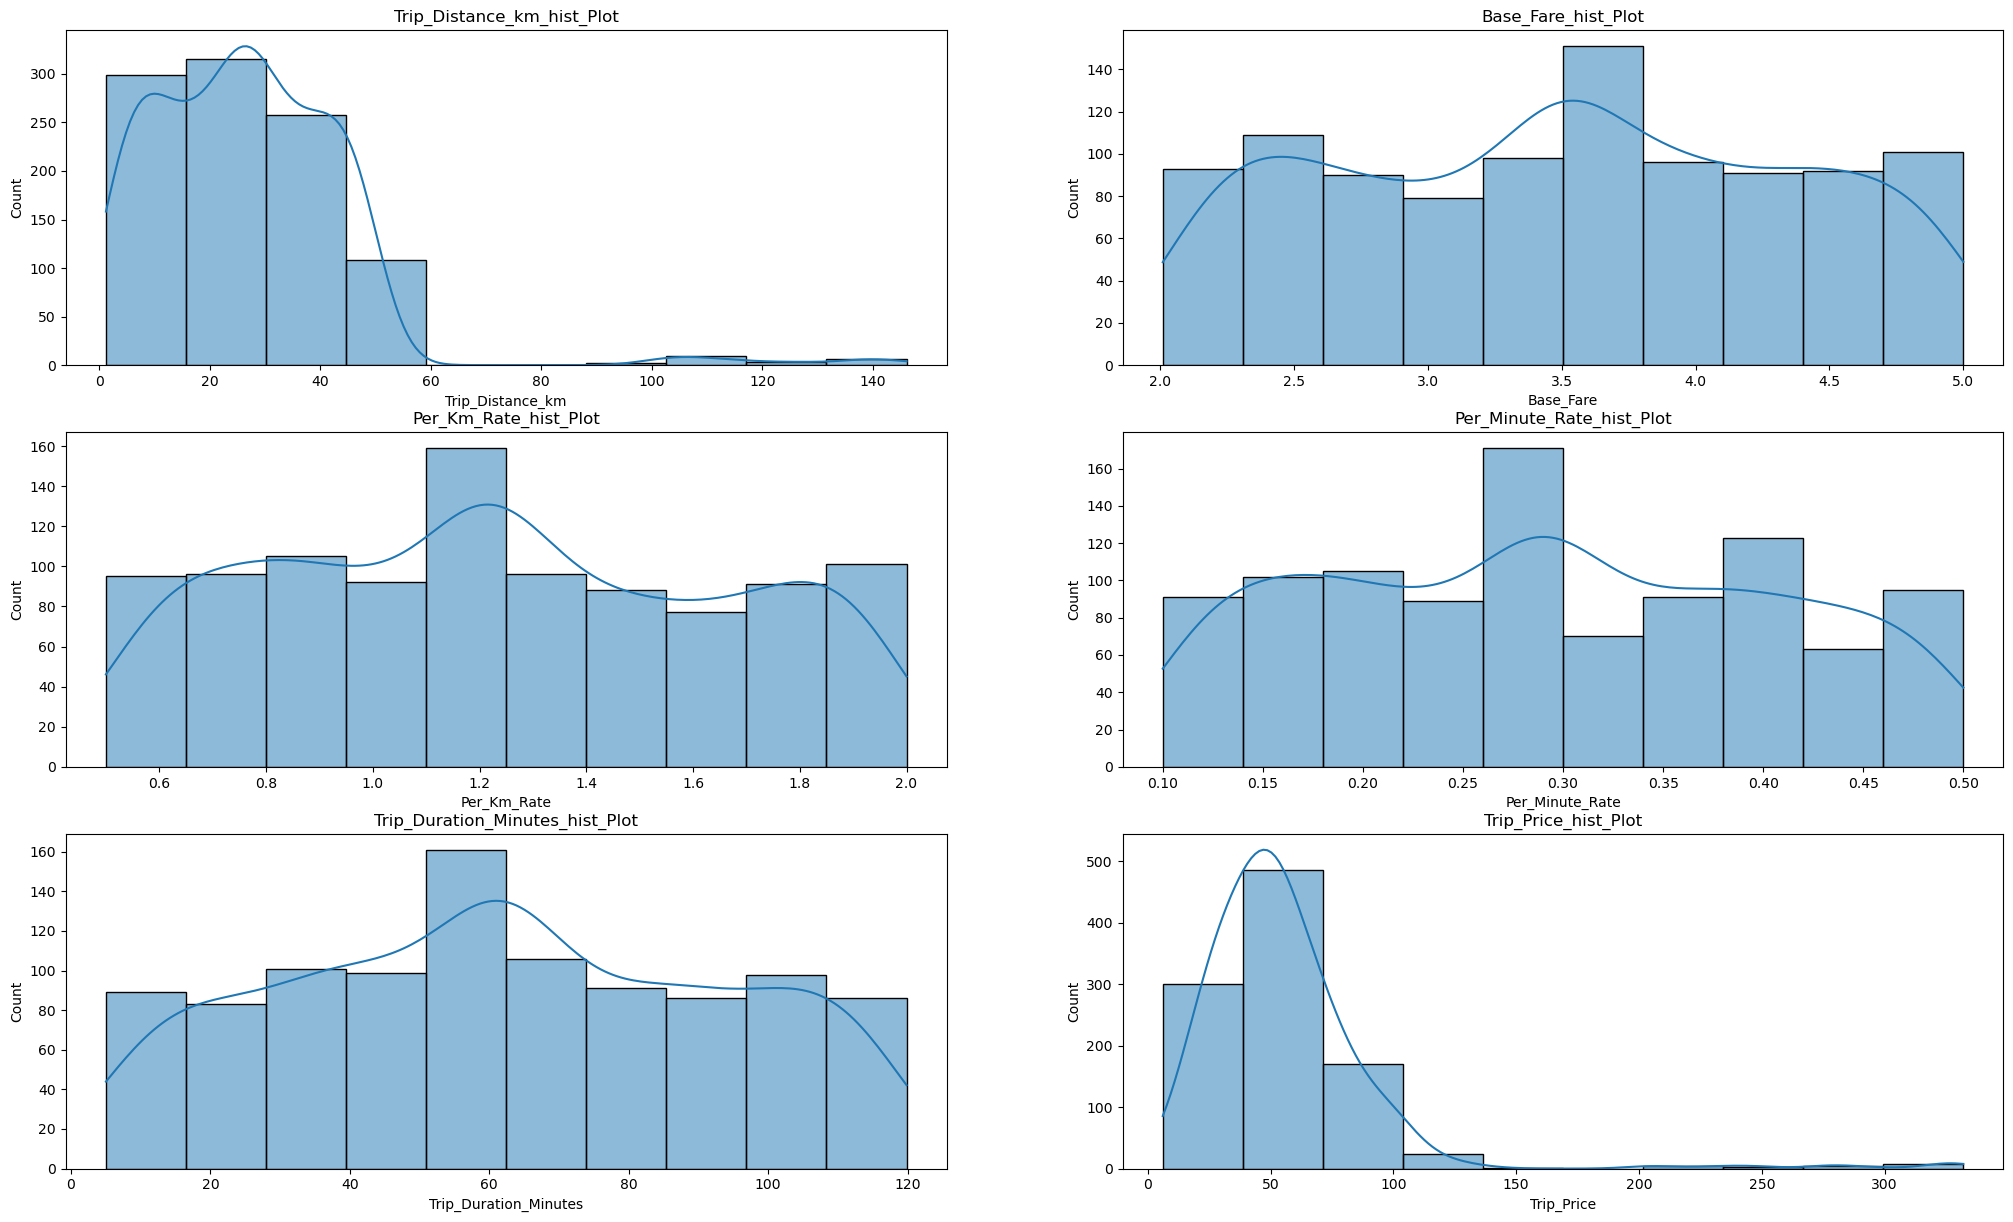

In [97]:
j=1
plt.figure(figsize=(25,20))
for i in range(len(continous)):
    plt.subplot(4,2,j)
    sns.histplot(data=df, bins = 10, x=continous[i], kde = True)
    plt.title(f'{continous[i]}_hist_Plot')
    j=j+1
plt.show()

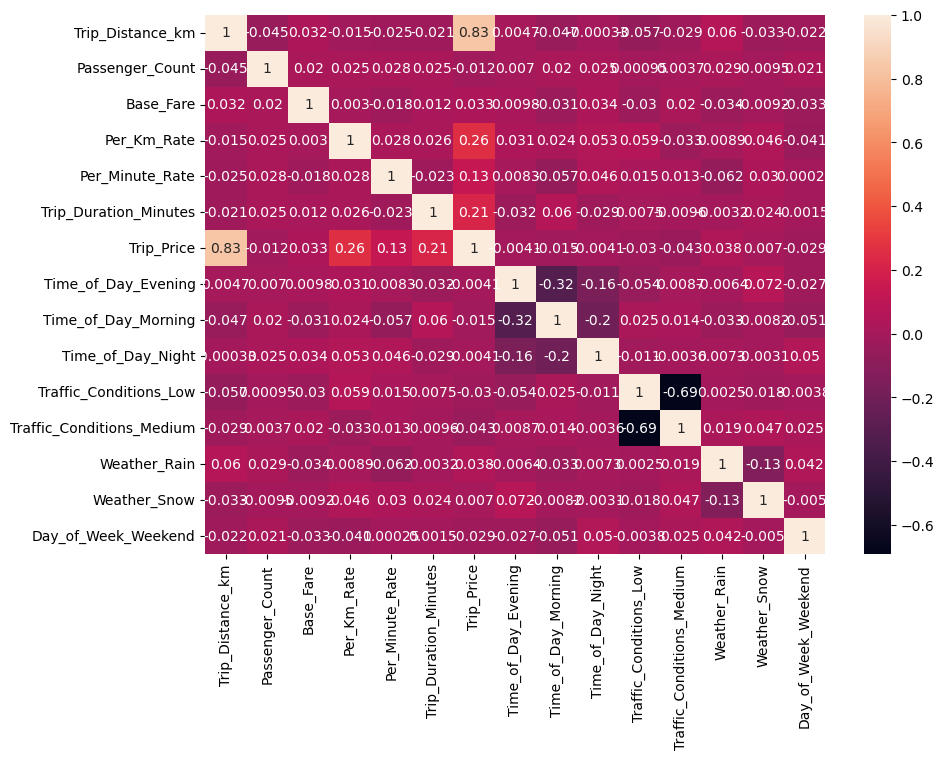

In [98]:
corr_data = df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_data, annot = True)
plt.show()

In [99]:
corr_data = df.corr()
corr_data

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow,Day_of_Week_Weekend
Trip_Distance_km,1.000000,-0.045072,0.031812,-0.015398,-0.025494,-0.020963,0.830479,0.004721,-0.047187,-0.000335,-0.056867,-0.029316,0.059784,-0.032503,-0.021809
Passenger_Count,-0.045072,1.000000,0.019717,0.025258,0.028360,0.024868,-0.012468,0.007008,0.020169,0.025122,0.000949,0.003717,0.029142,-0.009547,0.021068
Base_Fare,0.031812,0.019717,1.000000,0.002975,-0.018047,0.011585,0.033103,0.009826,-0.030946,0.034253,-0.030410,0.019598,-0.034278,-0.009159,-0.032782
Per_Km_Rate,-0.015398,0.025258,0.002975,1.000000,0.027585,0.025636,0.256122,0.031124,0.023805,0.053150,0.059013,-0.033238,0.008942,0.046031,-0.040856
Per_Minute_Rate,-0.025494,0.028360,-0.018047,0.027585,1.000000,-0.022913,0.131534,0.008339,-0.056657,0.046244,0.014500,0.013279,-0.061878,0.029542,0.000250
Trip_Duration_Minutes,-0.020963,0.024868,0.011585,0.025636,-0.022913,1.000000,0.214669,-0.032208,0.060173,-0.028838,0.007539,-0.009618,-0.003216,0.024440,0.001451
Trip_Price,0.830479,-0.012468,0.033103,0.256122,0.131534,0.214669,1.000000,-0.004144,-0.015372,-0.004098,-0.030014,-0.042553,0.037863,0.007010,-0.028516
Time_of_Day_Evening,0.004721,0.007008,0.009826,0.031124,0.008339,-0.032208,-0.004144,1.000000,-0.317068,-0.161606,-0.053710,0.008682,-0.006416,0.071711,-0.026631
Time_of_Day_Morning,-0.047187,0.020169,-0.030946,0.023805,-0.056657,0.060173,-0.015372,-0.317068,1.000000,-0.201174,0.024554,0.013819,-0.033075,-0.008188,-0.051040
Time_of_Day_Night,-0.000335,0.025122,0.034253,0.053150,0.046244,-0.028838,-0.004098,-0.161606,-0.201174,1.000000,-0.010880,-0.003585,0.007307,-0.003115,0.049566


In [100]:
df.columns


Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Weather_Rain',
       'Weather_Snow', 'Day_of_Week_Weekend'],
      dtype='object')

# Exploratory Data Analysis 

In [101]:
data = df[['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Weather_Rain',
       'Weather_Snow', 'Day_of_Week_Weekend']]
data

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow,Day_of_Week_Weekend
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0,1,0,1,0,0,0,0
1,47.59,1.0,3.52,0.62,0.43,40.57,50.0745,0,0,0,0,0,0,0,0
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,1,0,0,0,0,0,0,1
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,1,0,0,1,0,0,0,0
4,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,4.0,2.39,0.62,0.49,58.39,34.4049,0,0,0,0,1,0,0,1
996,45.95,4.0,3.12,0.61,0.29,61.96,62.1295,0,0,1,0,1,0,0,0
997,7.70,3.0,2.08,1.78,0.29,54.18,33.1236,0,1,0,1,0,1,0,0
998,47.56,1.0,2.67,0.82,0.17,114.94,61.2090,0,1,0,1,0,0,0,0


In [102]:
data.skew()

Trip_Distance_km             2.302844
Passenger_Count              0.078532
Base_Fare                   -0.008297
Per_Km_Rate                  0.086028
Per_Minute_Rate              0.064101
Trip_Duration_Minutes        0.019447
Trip_Price                   3.844391
Time_of_Day_Evening          1.478977
Time_of_Day_Morning          0.964915
Time_of_Day_Night            2.806929
Traffic_Conditions_Low       0.213522
Traffic_Conditions_Medium    0.534884
Weather_Rain                 1.305396
Weather_Snow                 3.867988
Day_of_Week_Weekend          0.900390
dtype: float64

In [103]:
data.mean()

Trip_Distance_km             27.00852
Passenger_Count               2.45300
Base_Fare                     3.50384
Per_Km_Rate                   1.23265
Per_Minute_Rate               0.29277
Trip_Duration_Minutes        62.10521
Trip_Price                   56.54156
Time_of_Day_Evening           0.20300
Time_of_Day_Morning           0.28300
Time_of_Day_Night             0.09300
Traffic_Conditions_Low        0.44700
Traffic_Conditions_Medium     0.37100
Weather_Rain                  0.22700
Weather_Snow                  0.05600
Day_of_Week_Weekend           0.29500
dtype: float64

In [104]:
data.median()

Trip_Distance_km             25.8300
Passenger_Count               2.0000
Base_Fare                     3.5200
Per_Km_Rate                   1.2200
Per_Minute_Rate               0.2900
Trip_Duration_Minutes        61.8600
Trip_Price                   50.0745
Time_of_Day_Evening           0.0000
Time_of_Day_Morning           0.0000
Time_of_Day_Night             0.0000
Traffic_Conditions_Low        0.0000
Traffic_Conditions_Medium     0.0000
Weather_Rain                  0.0000
Weather_Snow                  0.0000
Day_of_Week_Weekend           0.0000
dtype: float64

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

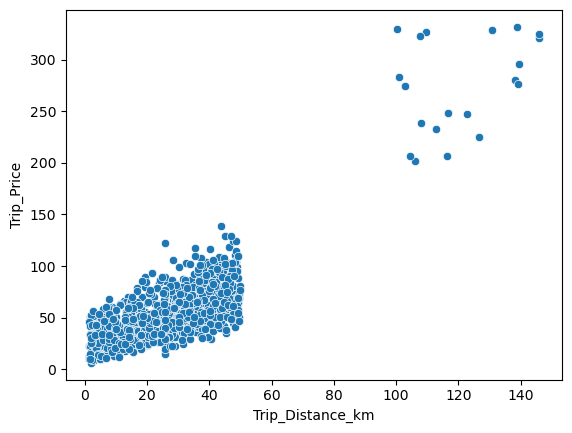

In [105]:
# relation between x ='Trip_Distance_km' , y = 'Trip_Price'
sns.scatterplot(x ='Trip_Distance_km' , y = 'Trip_Price', data = df)

<Axes: xlabel='Per_Km_Rate', ylabel='Trip_Price'>

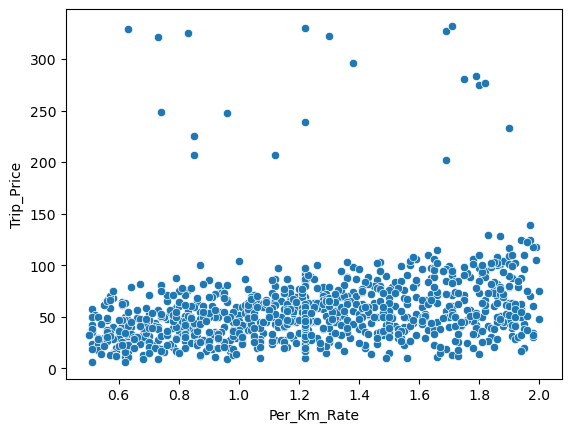

In [106]:
# relation between x ='Trip_Distance_km' , y = 'Trip_Price'
sns.scatterplot(x ='Per_Km_Rate' , y = 'Trip_Price', data = df)

<Axes: xlabel='Trip_Duration_Minutes', ylabel='Trip_Price'>

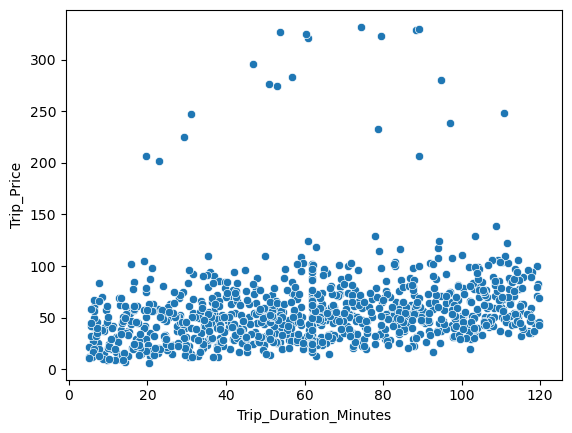

In [107]:
sns.scatterplot(x ='Trip_Duration_Minutes' , y = 'Trip_Price', data = df)

In [108]:
df['Time_of_Day_Night'].unique()

array([0, 1])

# Train Test Split

In [109]:
# Define features (X) and target (y)
X = data[['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Weather_Rain',
       'Weather_Snow', 'Day_of_Week_Weekend']]  # Features
y = data['Trip_Price']  # Target

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (800, 15)
Testing Features Shape: (200, 15)
Training Target Shape: (800,)
Testing Target Shape: (200,)


# Linear Regression



In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

# Get the slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")

# Predict the target values for the testing data
y_pred = model.predict(X_test)


# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")



Slope (m): -9.1197266047481e-16
Intercept (c): 0.0
Mean Squared Error: 2.3489516744313457e-28
R² Score: 1.0


In [112]:
# Calculate RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.53262900743505e-14


In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [117]:
slope = model.coef_[0]
intercept = model.intercept_

print('slope', slope)
print('intercept', intercept)



slope -9.1197266047481e-16
intercept 0.0


In [127]:
y_pred = model.predict(X_test)


In [129]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('mse', mse)
print('r2', r2)

mse 2.3489516744313457e-28
r2 1.0


In [131]:
RMSE = np.sqrt(mse)
RMSE

1.53262900743505e-14

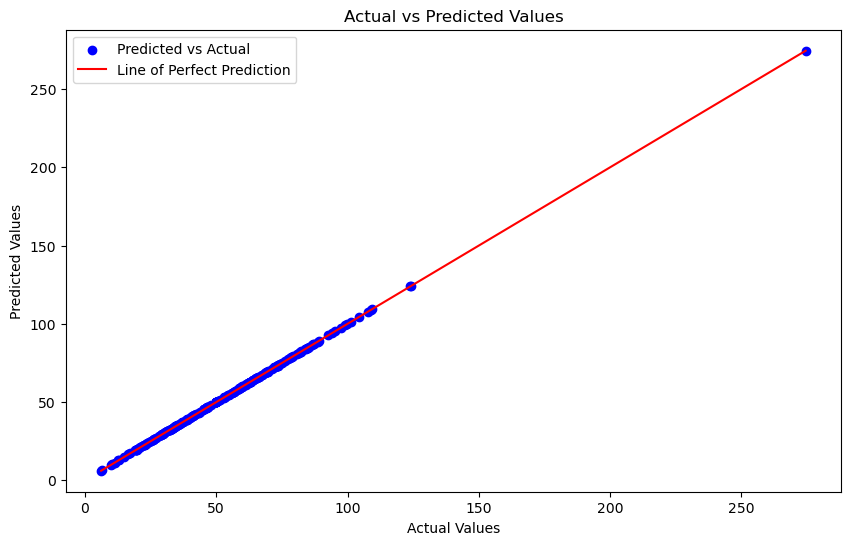

In [133]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Line of Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.title('Actual vs Predicted Values')
plt.show()
